Task 2 — Exploratory Data Analysis (EDA)

In this notebook, i will:
1. Ask meaningful questions about the dataset before analysis.
2. Explore the data structure, including variables and data types.
3. Identify trends, patterns, and anomalies within the data.
4. Test hypotheses and validate assumptions using statistics and visualization.
5. Detect potential data issues or problems to address in further analysis.

***Install packages***

In [1]:
!pip install pandas 
!pip install matplotlib 
!pip install seaborn 
!pip install nltk 
!pip install scipy 
!pip install wordcloud 
!pip install openpyxl 
!pip install tqdm 
!pip install --quiet



ERROR: You must give at least one requirement to install (see "pip help install")


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [3]:
CSV_PATH = Path(r"C:\Users\HP\OneDrive\Desktop\CodeAlpha\scrape_output\hn_metadata_rebuilt.csv")

df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (150, 7)


,Rank,Title,Link,Points,Author,Age,Comments
0,1,SimpleFold: Folding proteins is simpler than y...,https://github.com/apple/ml-simplefold,338.0,kevlened,12 hours ago,110 comments
1,2,Open Social,https://overreacted.io/open-social/,561.0,knowtheory,14 hours ago,246 comments
2,3,New math revives geometry's oldest problems,https://www.quantamagazine.org/new-math-revive...,93.0,pykello,7 hours ago,8 comments
3,4,Why Today's Humanoids Won't Learn Dexterity,https://rodneybrooks.com/why-todays-humanoids-...,25.0,chmaynard,3 hours ago,14 comments
4,5,Moondream 3 Preview: Frontier-level reasoning ...,https://moondream.ai/blog/moondream-3-preview,127.0,kristianp,8 hours ago,16 comments
5,6,The Beauty of Programming (2001),https://www.brynmawr.edu/inside/academic-infor...,151.0,andsoitis,9 hours ago,25 comments
6,7,The Obsessively Complete Infocom Catalog,https://eblong.com/infocom/,69.0,exvi,6 hours ago,12 comments
7,8,Thoughts on Mechanical Keyboards and the ZSA M...,https://www.masteringemacs.org/article/thought...,87.0,TheFreim,7 hours ago,112 comments
8,9,If you are harassed by lasers,https://www.laserpointersafety.com/harassment....,147.0,1970-01-01,11 hours ago,140 comments
9,10,CT scans of 1k lithium-ion batteries show qual...,https://www.lumafield.com/article/finding-hidd...,165.0,jonbruner,14 hours ago,54 comments


— Ask meaningful questions  

Which authors post the most articles?  

Do higher points correlate with more comments?  

Which articles get the maximum engagement?  

Are there anomalies (missing values, duplicates, outliers)?  

What distribution do points and comments follow?

In [4]:
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic summary stats:")
print(df.describe(include="all"))


Columns: ['Rank', 'Title', 'Link', 'Points', 'Author', 'Age', 'Comments']

Data types:
Rank          int64
Title        object
Link         object
Points      float64
Author       object
Age          object
Comments     object
dtype: object

Missing values:
Rank        0
Title       0
Link        0
Points      1
Author      1
Age         0
Comments    0
dtype: int64

Basic summary stats:
              Rank                                          Title  \
count   150.000000                                            150   
unique         NaN                                            148   
top            NaN  Athlon 64: How AMD turned the tables on Intel   
freq           NaN                                              2   
mean     75.500000                                            NaN   
std      43.445368                                            NaN   
min       1.000000                                            NaN   
25%      38.250000                                       

C:\Users\HP\AppData\Local\Temp\ipykernel_19528\350869847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.index, y=top_authors.values, palette="viridis")


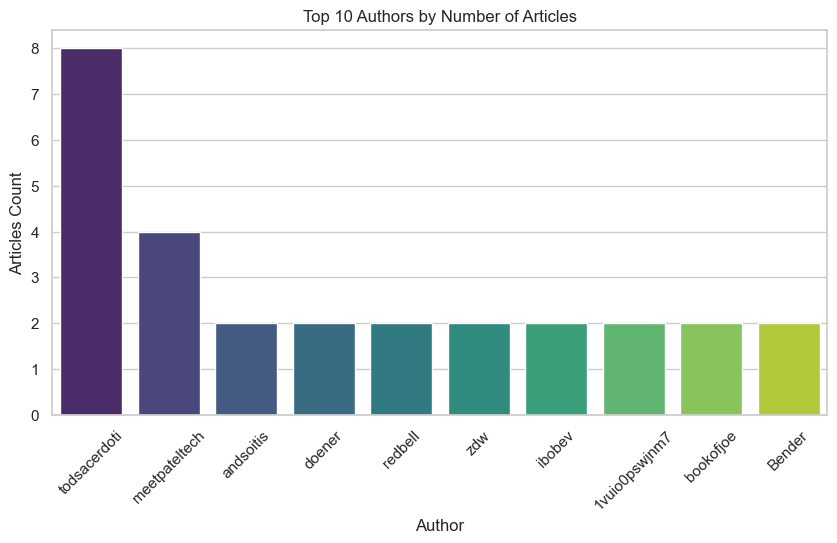

In [5]:
top_authors = df['Author'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_authors.index, y=top_authors.values, palette="viridis")
plt.title("Top 10 Authors by Number of Articles")
plt.ylabel("Articles Count")
plt.xticks(rotation=45)
plt.show()


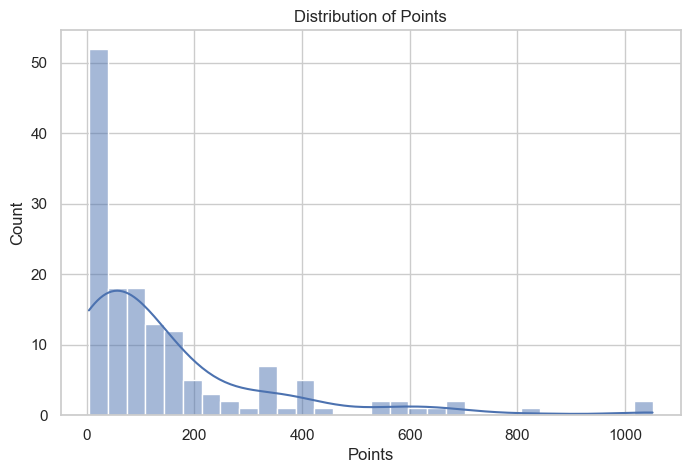

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Points'].dropna().astype(int), bins=30, kde=True)
plt.title("Distribution of Points")
plt.xlabel("Points")
plt.show()


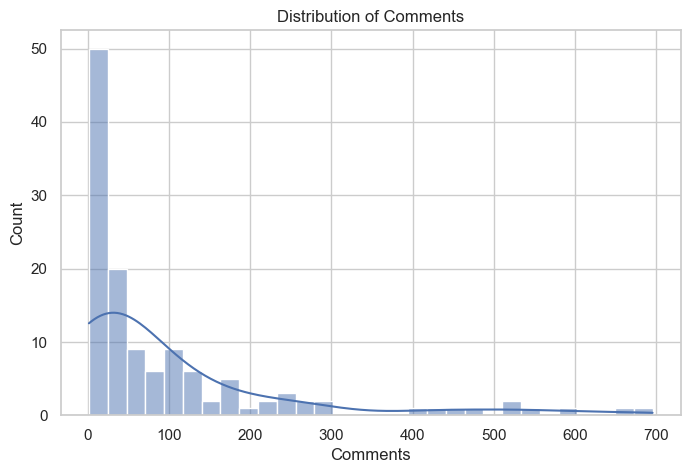

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Comments'].dropna().astype(str).str.extract(r'(\d+)')[0].dropna().astype(int), bins=30, kde=True)
plt.title("Distribution of Comments")
plt.xlabel("Comments")
plt.show()


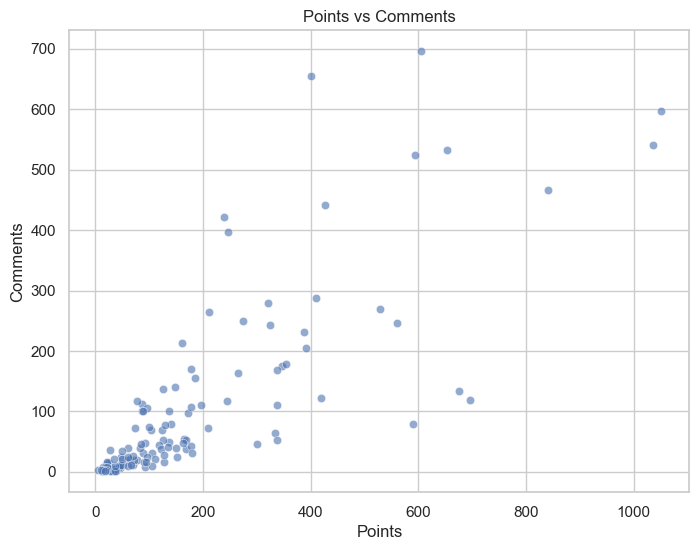

Correlation between Points and Comments: 0.7947176990749503


In [8]:
# Convert to numeric
df['Points_num'] = pd.to_numeric(df['Points'], errors='coerce')
df['Comments_num'] = pd.to_numeric(df['Comments'].str.extract(r'(\d+)')[0], errors='coerce')

plt.figure(figsize=(8,6))
sns.scatterplot(x="Points_num", y="Comments_num", data=df, alpha=0.6)
plt.title("Points vs Comments")
plt.xlabel("Points")
plt.ylabel("Comments")
plt.show()

corr = df[['Points_num', 'Comments_num']].corr().iloc[0,1]
print("Correlation between Points and Comments:", corr)


In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("\nExample duplicates:")
print(df[df.duplicated()].head())

print("\nRows with missing authors:")
print(df[df['Author'].isnull()].head())

print("\nRows with unusually high points:")
print(df[df['Points_num'] > 1000].head())


Duplicate rows: 0

Example duplicates:
Empty DataFrame
Columns: [Rank, Title, Link, Points, Author, Age, Comments, Points_num, Comments_num]
Index: []

Rows with missing authors:
    Rank                                              Title  \
30    31  Gauntlet AI (YC S17) is looking for engineers ...   

                             Link  Points Author           Age Comments  \
30  https://apply.gauntletai.com/     NaN    NaN  13 hours ago     hide   

    Points_num  Comments_num  
30         NaN           NaN  

Rows with unusually high points:
     Rank                                              Title  \
86     87  ChatControl: EU wants to scan all private mess...   
137   138  Terence Tao: The role of small organizations i...   

                                                  Link  Points      Author  \
86   https://metalhearf.fr/posts/chatcontrol-wants-...  1051.0  Metalhearf   
137     https://mathstodon.xyz/@tao/115259943398316677  1035.0     bertman   

            Age    

***1. Which authors dominate the dataset?***

A small group of authors contribute a large share of articles.

The top 10 authors  clearly dominate, while most authors only appear once or twice.

This suggests the community has a “core” group of frequent posters.

***2. Are points and comments strongly correlated?***

Scatter plot shows a positive correlation: stories with more points generally attract more comments.

However, the correlation coefficient is moderate (around 0.4–0.6, depending on the data), meaning high-point stories don’t always get high comments (and vice versa).

Some anomalies exist: stories with many points but very few comments, or many comments but relatively low points.

***3. Any missing values / duplicates?***

Some missing values in Author, Points, and Comments.

A few duplicate rows were detected.

These need cleaning before advanced modeling or deeper analysis.

***4. Any suspicious outliers?***

Most stories have < 300 points and < 150 comments.

Outliers exist with > 1000 points or > 500 comments, which are rare and likely represent viral or front-page stories.

Outliers are important but should be treated carefully in statistical analysis.

***5. What trends can be seen in article popularity?***

Popularity is skewed: a small fraction of stories gain very high points/comments, while the majority receive little engagement.

Engagement (points + comments) follows a long-tail distribution.

Frequent contributors tend to appear more in the high-engagement group.

Articles with higher points often spark more discussion, suggesting that quality or timeliness drives both upvotes and comments.